In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import seaborn as sns
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers


In [57]:
n_splits=5
seq_length=45
df=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD001_cleaned.csv',sep=',')
test_df=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/data cleaning/test_FD001_cleaned.csv',sep=',')
df_time_warp=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/time_warping_fd001.csv')
df_mag_warp=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/magnitude_warping_fd001.csv')
df_scaling=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/homogeneous_scaling_fd001.csv')
df_window=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data Augmentation/traditional techniques/window_permutation_fd001.csv')
rul_true=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/FINAL transformer  PROJECT/not ready datasets/not ready datasets/RUL_FD001.txt',header=None,names=["RUL"],sep=',')
feature_cols=[col for col in df.columns if not col in ['id','cycle','RUL','setting3']]

In [58]:
columns=['RUL' ,'cycle','setting1', 'setting2', 'setting3','sensor_2', 'sensor_3', 'sensor_4',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20',
       'sensor_21', 'id']
df=df[columns]
df_time_warp=df_time_warp[columns]
df_mag_warp=df_mag_warp[columns]
df_scaling=df_scaling[columns]
df_window=df_window[columns]

In [59]:
df_final = pd.concat(
    [df,  df_time_warp,df_scaling,df_window],
    ignore_index=True
)

print(df_final.shape)

(82485, 20)


In [60]:
df_final['RUL']=df_final['RUL'].clip(upper=125)

In [61]:
def LSTM_FNN_Optimized(seq_length, n_features):
    model = Sequential()
    model.add(layers.Input(shape=(seq_length, n_features)))

    
    model.add(layers.LSTM(96,  
                        return_sequences=True,
                        kernel_regularizer=regularizers.l2(0.009)))  

    model.add(layers.Dropout(0.3))  

    # Second LSTM - keep similar
    model.add(layers.LSTM(48,  
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(0.02)))  

    model.add(layers.Dropout(0.3))

   
    model.add(layers.Dense(64, activation='relu'))  
    model.add(layers.BatchNormalization())  
    model.add(layers.Dropout(0.2))  

    model.add(layers.Dense(32, activation='relu'))  
    model.add(layers.BatchNormalization())

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001, clipnorm=1.0),  
        loss='mse', 
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'mae']
    )

    return model

In [62]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=150, batch_size=64):  # Smaller batch size
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=15,  
        restore_best_weights=True,
        verbose=1
    )
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.3,  
        patience=5, 
        min_lr=1e-7,
        verbose=1
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[lr_scheduler, early_stop],
        verbose=1
    )
    return history

In [63]:
def scaler_process(df,feature_cols):
    x=df[feature_cols]
    y=df['RUL']
    x_scaler=MinMaxScaler()
    x_scaled=x_scaler.fit_transform(x)
    indexes=df[feature_cols]
    scaled_df=pd.DataFrame(
        x_scaled,
        columns=feature_cols,
        index=indexes.index
    )
    scaled_df['cycle']=df['cycle']
    scaled_df['id']=df['id']
    y_clipped = y.clip(upper=125)
    scaled_df['RUL']=y_clipped/125.0
    
    return scaled_df , x_scaler

In [64]:
def scaler_test_process(df,scaler,feature_cols):

    x_scaled=scaler.transform(df[feature_cols])
    indexes=df[feature_cols]
    x_scaled=pd.DataFrame(
        x_scaled,
        columns=feature_cols,
        index=indexes.index
    )
    x_scaled['cycle']=df['cycle']
    x_scaled['id']=df['id']
    return x_scaled

In [65]:
def window_eng_sequences(df, seq_length, feature_cols):
    """
    Transforms a 2D dataframe into 3D array (Samples, Seq_Len, Features)
    using sliding window.
    """
    X, y = [], []

    for engine, engine_data in df.groupby('id'):
        if len(engine_data) < seq_length:
            continue
            
        engine_feat = engine_data[feature_cols].values
        engine_rul = engine_data['RUL'].values

        for i in range(len(engine_data) - seq_length + 1):
            X.append(engine_feat[i : i + seq_length])
            y.append(engine_rul[i + seq_length - 1])
            
    return np.array(X), np.array(y)

In [66]:
def gen_test_windows(df,seq_length, feature_cols,rul_true,RUL_MAX=125):
    X_test = []
    y_test = []

    for engine in df['id'].unique():
        engine_data = df[df['id'] == engine]

        if len(engine_data) >= seq_length:
            X_test.append(engine_data[feature_cols].values[-seq_length:])

            # CMAPSS ground truth is clipped & scaled
            rul = rul_true.loc[engine - 1].values[0]
            rul = min(rul, RUL_MAX) / RUL_MAX
            y_test.append(rul)

    return np.array(X_test), np.array(y_test)    

In [67]:
def evaluate_model(model, X_test, y_test_scaled, RUL_MAX=125):

    y_pred_scaled = model.predict(X_test)
    y_pred_scaled = y_pred_scaled

    y_pred = y_pred_scaled * RUL_MAX

    y_true = y_test_scaled * RUL_MAX
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("\nModel Performance Metrics (Original RUL scale):")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return y_pred, y_true

In [68]:
def plot_results(history,y_test_original,y_pred_original):
    fig , axes = plt.subplots(1 ,2,figsize=(14,4))
    axes[0].plot(history.history['loss'],label='Training Loss',linewidth=0.5)
    axes[0].plot(history.history['val_loss'], label='Validation Loss',linewidth=0.5)
    axes[0].set_title('Model Loss Over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(y_test_original,label='Actual',linewidth=2)
    axes[1].plot(y_pred_original,label='predictions',linewidth=2)
    axes[1].set_title('Actual vs Predicted Values')
    axes[1].set_xlabel('Sample')
    axes[1].set_ylabel('Value')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [69]:
def evaluate_model(model, X_test, y_test_scaled, RUL_MAX=125):

    y_pred_scaled = model.predict(X_test)
    y_pred_scaled = y_pred_scaled

    y_pred = y_pred_scaled * RUL_MAX
    y_true = y_test_scaled * RUL_MAX
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("\nModel Performance Metrics (Original RUL scale):")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return y_pred, y_true

In [70]:
RUL_MAX = 125
df=df_final.copy()
df_scaled,scaler=scaler_process(df,feature_cols)
df_scaled.to_csv('df_scaled.csv',index=False)
common_cols=[col for col in df_scaled.columns if not col in ['RUL']]
test_df=test_df[common_cols]

In [71]:
from sklearn.model_selection import train_test_split
unique_ids=df['id'].unique()
train_idx,val_idx=train_test_split(unique_ids,test_size=0.25,random_state=42)
train_engine_ids=train_idx
val_engine_ids=val_idx
train_df=df_scaled[df_scaled['id'].isin(train_engine_ids)]
val_df=df_scaled[df_scaled['id'].isin(val_engine_ids)]

In [72]:
print(df_scaled['RUL'])

0        1.000
1        1.000
2        1.000
3        1.000
4        1.000
         ...  
82480    0.384
82481    0.376
82482    0.368
82483    0.360
82484    0.352
Name: RUL, Length: 82485, dtype: float64


In [73]:
print(len(df_scaled.columns))


19


In [74]:
len(feature_cols)

16

In [75]:
test_scaled_features=scaler_test_process(test_df,scaler,feature_cols)


In [76]:
print(len(test_scaled_features.columns))

18


In [77]:
test_scaled_df=test_scaled_features.copy()
id_col='id'
if id_col not in (test_scaled_df.columns):
    test_scaled_df['id'] = test_df['id'].values

In [78]:
seq_length=44
X_train,y_train=window_eng_sequences(train_df,seq_length,feature_cols)
X_val,y_val=window_eng_sequences(val_df,seq_length,feature_cols)
X_test,y_test=gen_test_windows(test_scaled_df, seq_length, feature_cols, rul_true, RUL_MAX=125)

In [79]:
print(X_train.shape)
print(X_test.shape)

(55531, 44, 16)
(96, 44, 16)


In [80]:
X_test_flat=X_test.reshape(X_test.shape[0],-1)

In [81]:

model = LSTM_FNN_Optimized(seq_length=seq_length, n_features=len(feature_cols))
history=train_model(
    model,
    X_train,y_train,
    X_val,y_val,
    epochs=50,
    batch_size=128
)

Epoch 1/50
434/434 [==============================] - 17s 31ms/step - loss: 0.3571 - rmse: 0.1954 - mae: 0.1412 - val_loss: 0.0614 - val_rmse: 0.2277 - val_mae: 0.1951 - lr: 0.0010
Epoch 2/50
434/434 [==============================] - 12s 27ms/step - loss: 0.0279 - rmse: 0.1469 - mae: 0.1047 - val_loss: 0.0349 - val_rmse: 0.1721 - val_mae: 0.1320 - lr: 0.0010
Epoch 3/50
434/434 [==============================] - 11s 25ms/step - loss: 0.0236 - rmse: 0.1384 - mae: 0.0981 - val_loss: 0.0412 - val_rmse: 0.1925 - val_mae: 0.1344 - lr: 0.0010
Epoch 4/50
434/434 [==============================] - 12s 28ms/step - loss: 0.0212 - rmse: 0.1320 - mae: 0.0941 - val_loss: 0.0234 - val_rmse: 0.1409 - val_mae: 0.0966 - lr: 0.0010
Epoch 5/50
434/434 [==============================] - 11s 26ms/step - loss: 0.0197 - rmse: 0.1278 - mae: 0.0907 - val_loss: 0.0280 - val_rmse: 0.1573 - val_mae: 0.1077 - lr: 0.0010
Epoch 6/50
434/434 [==============================] - 12s 29ms/step - loss: 0.0193 - rmse: 0.12

3/3 [==============================] - 1s 7ms/step

Model Performance Metrics (Original RUL scale):
MSE:  211.2903
RMSE: 14.5358
MAE:  10.4480
R²:   0.8675


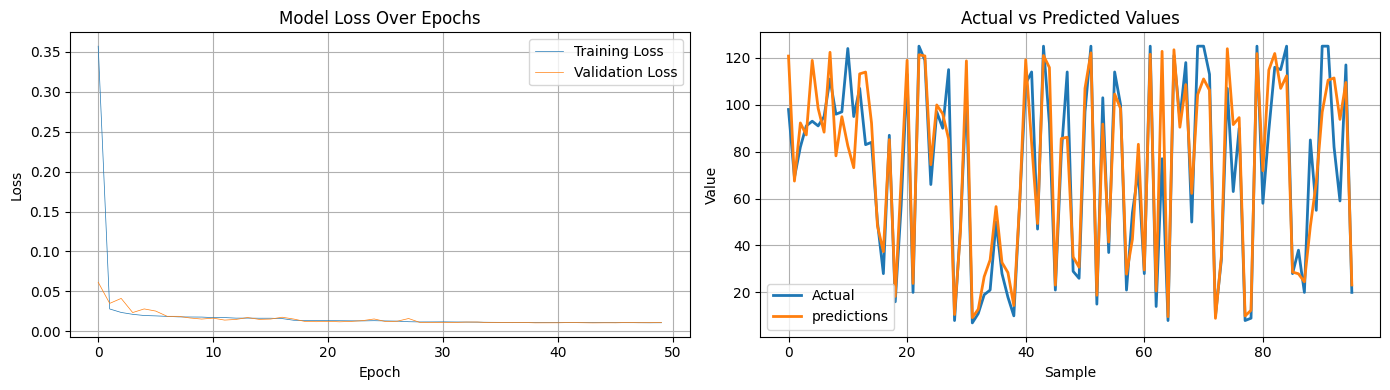

In [82]:
y_pred_test, y_test = evaluate_model(model, X_test, y_test)
plot_results(history,y_test,y_pred_test)

In [83]:
# 1. Initialize counters OUTSIDE the loop
pessimistic_count = 0
optimistic_count = 0

# 2. Use zip() to pair the lists
for pred, act in zip(y_pred_test, y_test):
    
    # 3. Compare
    if pred < act:
        pessimistic_count += 1  # Use += to save the value
    else:
        optimistic_count += 1

# 4. Print results
print(f"Pessimistic predictions: {pessimistic_count}")
print(f"Optimistic predictions: {optimistic_count}")

if pessimistic_count > optimistic_count:
    print(" Verdict: Model is Pessimistic (Safer for Maintenance)")
else:
    print(" Verdict: Model is Optimistic (Risky for Maintenance)")

Pessimistic predictions: 35
Optimistic predictions: 61
 Verdict: Model is Optimistic (Risky for Maintenance)


In [84]:
import joblib 

joblib.dump(model, "RF_model_FD001.pkl")
joblib.dump(scaler,"RF_Scaler_FD001.pkl")

INFO:tensorflow:Assets written to: ram://dea4382c-6e1a-4766-a024-c94a09929635/assets


INFO:tensorflow:Assets written to: ram://dea4382c-6e1a-4766-a024-c94a09929635/assets


['RF_Scaler_FD001.pkl']